<a href="https://colab.research.google.com/github/mfernandezzz/Pruebas_Tecnicas/blob/main/TT_stack_overflow_two.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
schema = pd.read_csv('/content/schema.csv')
df = pd.read_csv('/content/results.csv', low_memory=False)

In [4]:
schema.shape

(87, 6)

In [5]:
df.shape

(49191, 172)

**¿Que porcentaje de devs usa IA y cuanto cobran vs los usuarios que no usan IA?**

In [6]:
schema.columns

Index(['qid', 'qname', 'question', 'force_resp', 'type', 'selector'], dtype='object')

In [ ]:
schema['question'].unique()

array(['Which of the following options best describes you today? For the purpose of this survey, a developer is "someone who writes code".*',
       'What is your age?*',
       'Which of the following best describes your current employment status? Select all that apply.*',
       'Which best describes your current work situation?',
       'Just checking to make sure you are paying attention to the survey questions. Select ‘Apples’ from the list and you can get back to the survey.*<br><br>',
       'Which of the following best describes the code you write outside of work? Select all that apply.',
       'Which of the following best describes the highest level of formal education that you’ve completed? *',
       'How do you learn to code? Select all that apply.',
       'What online resources do you use to learn to code? Select all that apply.',
       'What is the source of the technical documentation you use most often to learn to code?  Select all that apply.',
       'Including any

In [7]:
schema.loc[schema['question'] == 'Do you currently use AI tools in your development process? *']

,qid,qname,question,force_resp,type,selector
39,QID314,AISelect,Do you currently use AI tools in your developm...,True,MC,SAVR


In [8]:
df.columns

Index(['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment',
       'EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode',
       'LearnCodeAI',
       ...
       'AIAgentOrchestration', 'AIAgentOrchWrite', 'AIAgentObserveSecure',
       'AIAgentObsWrite', 'AIAgentExternal', 'AIAgentExtWrite', 'AIHuman',
       'AIOpen', 'ConvertedCompYearly', 'JobSat'],
      dtype='object', length=172)

In [9]:
df['AISelect'].dtype

dtype('O')

In [10]:
df['AISelect'].unique()

array(['Yes, I use AI tools monthly or infrequently',
       'Yes, I use AI tools weekly', 'Yes, I use AI tools daily',
       "No, and I don't plan to", nan, 'No, but I plan to soon'],
      dtype=object)

In [11]:
df_ai_select = pd.DataFrame(df['AISelect'].value_counts()).reset_index()
df_ai_select.rename(columns={'count': 'devs'}, inplace=True)
df_ai_select['%'] = round((df_ai_select['devs'] / df_ai_select['devs'].sum()) * 100, 2)
df_ai_select

,AISelect,devs,%
0,"Yes, I use AI tools daily",15883,47.10
1,"Yes, I use AI tools weekly",5958,17.67
2,"No, and I don't plan to",5454,16.17
3,"Yes, I use AI tools monthly or infrequently",4628,13.72
4,"No, but I plan to soon",1797,5.33


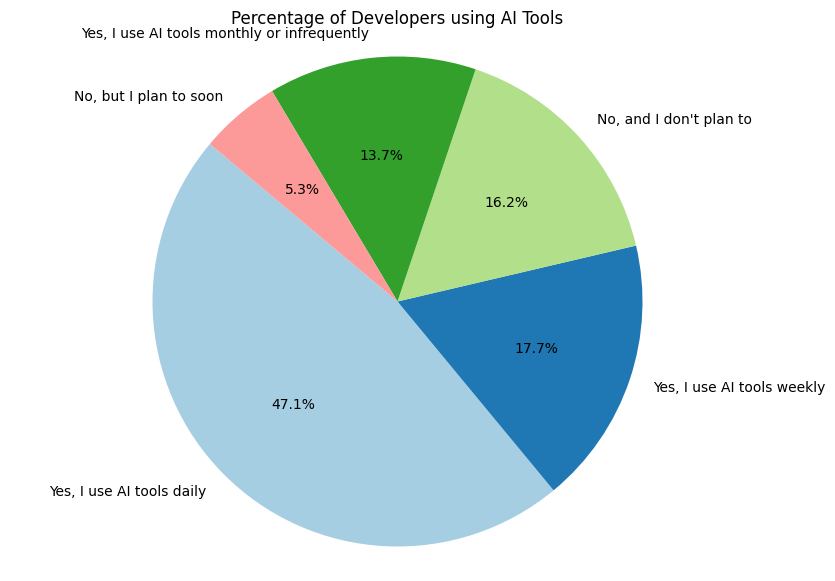

In [12]:
import matplotlib.pyplot as plt

# Create a pie chart using df_ai_select
plt.figure(figsize=(10, 7))
plt.pie(df_ai_select['%'], labels=df_ai_select['AISelect'], autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Percentage of Developers using AI Tools')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [13]:
mask_ai_positive = (df['AISelect'] == 'Yes, I use AI tools daily') | (df['AISelect'] == 'Yes, I use AI tools weekly')
df_ai_positive = df.loc[mask_ai_positive][['ConvertedCompYearly']]
df_ai_positive.shape

(21841, 1)

In [14]:
salary_dev_use_ai = df_ai_positive.median().iloc[0]
salary_dev_use_ai

np.float64(73375.0)

In [15]:
mask_ai_negative = (df['AISelect'] == "No, and I don't plan to") | (df['AISelect'] == 'No, but I plan to soon') | (df['AISelect'] == 'Yes, I use AI tools monthly or infrequently')
df_ai_negative = df.loc[mask_ai_negative][['ConvertedCompYearly']]
df_ai_negative.shape

(11879, 1)

In [16]:
salary_dev_not_use_ai = df_ai_negative.median().iloc[0]
salary_dev_not_use_ai

np.float64(80000.0)

In [20]:
print(f'Porcentaje de Devs que utilizan IA diariamente o semanalmente: {round((df_ai_select.iloc[0]['%']) + (df_ai_select.iloc[1]['%']), 2)}%. Salario anual: {salary_dev_use_ai} dolares.')
print(f'Porcentaje de Devs que no utiliza IA: {round((df_ai_select.iloc[2]['%']) + (df_ai_select.iloc[4]['%']) + (df_ai_select.iloc[3]['%']), 2)}%. Salario anual: {salary_dev_not_use_ai} dolares.')

Porcentaje de Devs que utilizan IA diariamente o semanalmente: 64.77%. Salario anual: 73375.0 dolares.
Porcentaje de Devs que no utiliza IA: 35.22%. Salario anual: 80000.0 dolares.


### Comparación de Compensación Media
Calculamos la mediana de `ConvertedCompYearly` para entender mejor la diferencia salarial entre ambos grupos.

In [21]:
# Calculate medians
median_ai_users = df_ai_positive['ConvertedCompYearly'].median()
median_non_ai_users = df_ai_negative['ConvertedCompYearly'].median()

# Create a summary DataFrame for comparison
comparison_df = pd.DataFrame({
    'Grupo': ['Usa IA (Diario/Semanal)', 'No usa IA / Otros'],
    'Mediana Salario Anual (USD)': [median_ai_users, median_non_ai_users]
})

display(comparison_df)

# Calculate the difference
diff = median_non_ai_users - median_ai_users
print(f"\nLa diferencia en la compensación media es de ${diff:,.2f} a favor de quienes no usan IA diariamente/semanalmente.")

,Grupo,Mediana Salario Anual (USD)
0,Usa IA (Diario/Semanal),73375.0
1,No usa IA / Otros,80000.0



La diferencia en la compensación media es de $6,625.00 a favor de quienes no usan IA diariamente/semanalmente.


Otra solucion

In [22]:
df_ai_select

,AISelect,devs,%
0,"Yes, I use AI tools daily",15883,47.10
1,"Yes, I use AI tools weekly",5958,17.67
2,"No, and I don't plan to",5454,16.17
3,"Yes, I use AI tools monthly or infrequently",4628,13.72
4,"No, but I plan to soon",1797,5.33


In [46]:
df_ai_select.set_index('AISelect', inplace=True)
df_ai_select

,devs,%
AISelect,,
"Yes, I use AI tools daily",15883,47.10
"Yes, I use AI tools weekly",5958,17.67
"No, and I don't plan to",5454,16.17
"Yes, I use AI tools monthly or infrequently",4628,13.72
"No, but I plan to soon",1797,5.33


In [53]:
aiselect_salaries = df.groupby('AISelect')['ConvertedCompYearly'].median().sort_values(ascending=False)
aiselect_salaries

,ConvertedCompYearly
AISelect,
"No, and I don't plan to",81210.0
"No, but I plan to soon",79141.0
"Yes, I use AI tools monthly or infrequently",78890.0
"Yes, I use AI tools weekly",75410.0
"Yes, I use AI tools daily",72229.0


In [55]:
aiselect_devs = pd.concat([df_ai_select, aiselect_salaries], axis='columns').reset_index()
aiselect_devs.rename(columns={'ConvertedCompYearly': 'median_salary'}, inplace=True)
aiselect_devs

,AISelect,devs,%,median_salary
0,"Yes, I use AI tools daily",15883,47.10,72229.0
1,"Yes, I use AI tools weekly",5958,17.67,75410.0
2,"No, and I don't plan to",5454,16.17,81210.0
3,"Yes, I use AI tools monthly or infrequently",4628,13.72,78890.0
4,"No, but I plan to soon",1797,5.33,79141.0


Otra solucion

In [56]:
df_clean = df[df['ConvertedCompYearly'].notna()]
df_clean.shape

(23947, 172)

In [62]:
dev_ai = pd.DataFrame(df_clean['AISelect'].value_counts())
dev_ai.rename(columns={'count': 'devs'}, inplace=True)
dev_ai['%'] = round((dev_ai['devs'] / dev_ai['devs'].sum()) * 100, 2)
dev_ai

,devs,%
AISelect,,
"Yes, I use AI tools daily",11435,49.28
"Yes, I use AI tools weekly",4207,18.13
"No, and I don't plan to",3384,14.58
"Yes, I use AI tools monthly or infrequently",3078,13.27
"No, but I plan to soon",1099,4.74


In [63]:
dev_salary_ai = df_clean.groupby('AISelect')['ConvertedCompYearly'].median()
dev_salary_ai

,ConvertedCompYearly
AISelect,
"No, and I don't plan to",81210.0
"No, but I plan to soon",79141.0
"Yes, I use AI tools daily",72229.0
"Yes, I use AI tools monthly or infrequently",78890.0
"Yes, I use AI tools weekly",75410.0


In [67]:
result = pd.concat([dev_ai, dev_salary_ai], axis='columns').reset_index()
result.rename(columns={'ConvertedCompYearly': 'median_salary'}, inplace=True)
result

,AISelect,devs,%,median_salary
0,"Yes, I use AI tools daily",11435,49.28,72229.0
1,"Yes, I use AI tools weekly",4207,18.13,75410.0
2,"No, and I don't plan to",3384,14.58,81210.0
3,"Yes, I use AI tools monthly or infrequently",3078,13.27,78890.0
4,"No, but I plan to soon",1099,4.74,79141.0
